# 07 — Analyse des Séries Chronologiques

## Objectif

Le modèle actuel est une **régression statique** : il prédit les effectifs à partir des caractéristiques démographiques actuelles, sans tenir compte de la dynamique historique.

Ce notebook explore **deux approches temporelles** :

1. **Features de lag** : ajouter les effectifs des années précédentes comme variables explicatives (enrichissement du Gradient Boosting)
2. **Modèle Prophet** : décomposition trend/saisonnalité pour la prévision sur horizon long (3-5 ans)

## Quand utiliser quoi ?

| Cas d'usage | Approche recommandée |
|---|---|
| Prédire les effectifs de l'an prochain | Features de lag + GB |
| Tendance sur 5 ans pour décision PLU | Prophet / ARIMA |
| Comprendre une commune en développement | Les deux + analyse manuelle |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import shap

from p13.db import read_sql
from p13.ml.features import (
    FEATURE_COLUMNS, ALL_TARGETS, FEATURE_COLUMNS_ENGINEERED,
    LAG_LAGS, LAG_WINDOWS, SPATIAL_GROUP_COLUMN,
)
from p13.ml.feature_engineering import (
    add_interaction_features,
    add_lag_features,
    get_lag_feature_names,
    spatial_train_test_split,
)

sns.set_theme(style='whitegrid', palette='muted')
print('Librairies chargées.')

Librairies chargées.


## 1. Chargement et exploration temporelle

In [2]:
df_raw = read_sql("""
    SELECT *
    FROM ml_dataset_commune
    WHERE nb_eleves_maternelle IS NOT NULL
    ORDER BY code_insee, rentree
""")

rentrees = sorted(df_raw['rentree'].unique())
n_communes = df_raw['code_insee'].nunique()
print(f"Dataset : {df_raw.shape[0]} lignes | {n_communes} communes")
print(f"Rentrées disponibles : {rentrees}")
print(f"Observations par commune en moyenne : {df_raw.groupby('code_insee').size().mean():.1f}")

Dataset : 688 lignes | 43 communes
Rentrées disponibles : [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Observations par commune en moyenne : 16.0


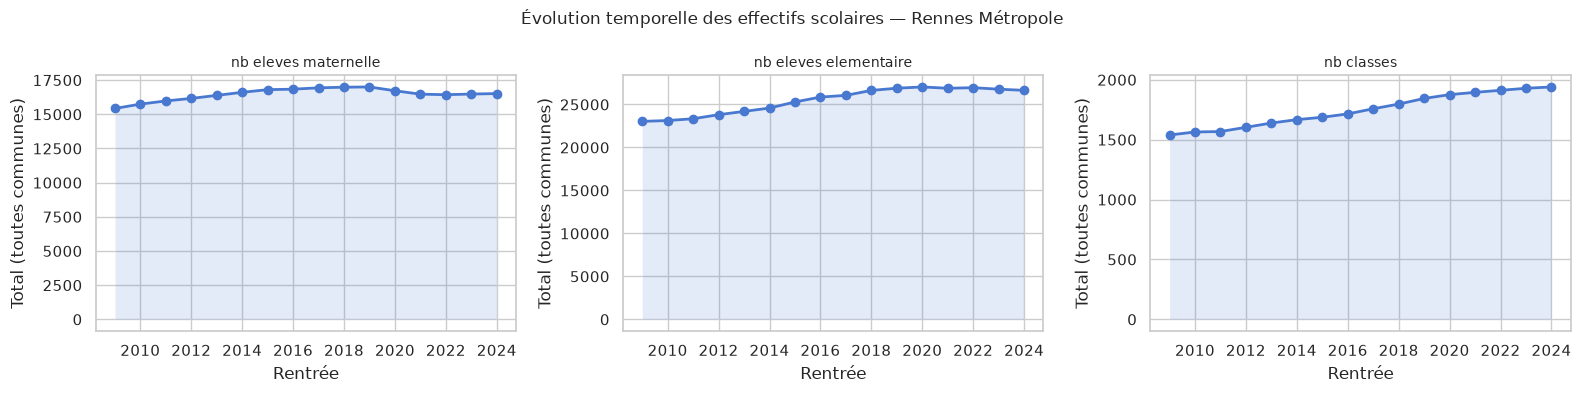

In [3]:
# Évolution temporelle globale (agrégée sur toutes les communes)
df_agg = df_raw.groupby('rentree')[ALL_TARGETS].sum().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, target in zip(axes, ALL_TARGETS):
    ax.plot(df_agg['rentree'], df_agg[target], marker='o', linewidth=2)
    ax.fill_between(df_agg['rentree'], df_agg[target], alpha=0.15)
    ax.set_title(target.replace('_', ' '), fontsize=10)
    ax.set_xlabel('Rentrée')
    ax.set_ylabel('Total (toutes communes)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.suptitle('Évolution temporelle des effectifs scolaires — Rennes Métropole', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Création des features de lag

Pour chaque commune et chaque cible, on crée :
- `target_lag1` : effectif de l'année N-1 (mémoire directe)
- `target_lag2`, `target_lag3` : effectifs N-2, N-3 (tendance)
- `target_rolling_mean3` : moyenne glissante sur 3 ans (signal lissé)
- `target_delta1` : variation N-1 → N-2 (vitesse de changement)

In [4]:
df_eng = add_interaction_features(df_raw)
df_lag = add_lag_features(
    df_eng,
    target_cols=ALL_TARGETS,
    group_col=SPATIAL_GROUP_COLUMN,
    time_col='rentree',
    lags=LAG_LAGS,
    rolling_windows=LAG_WINDOWS,
)

lag_col_names = get_lag_feature_names(ALL_TARGETS, lags=LAG_LAGS, rolling_windows=LAG_WINDOWS)

print(f"Features de lag créées : {len(lag_col_names)}")
print("\nExemple pour une commune (triée par rentrée) :")

exemple_col = 'code_insee'
exemple_commune = df_lag['code_insee'].value_counts().index[0]
cols_show = ['code_insee', 'rentree', 'nb_eleves_elementaire',
             'nb_eleves_elementaire_lag1', 'nb_eleves_elementaire_lag2',
             'nb_eleves_elementaire_rolling_mean3', 'nb_eleves_elementaire_delta1']
cols_show = [c for c in cols_show if c in df_lag.columns]
print(df_lag[df_lag['code_insee'] == exemple_commune][cols_show].to_string(index=False))

Features de lag créées : 15

Exemple pour une commune (triée par rentrée) :
code_insee  rentree  nb_eleves_elementaire  nb_eleves_elementaire_lag1  nb_eleves_elementaire_lag2  nb_eleves_elementaire_rolling_mean3  nb_eleves_elementaire_delta1
     35001     2009                  487.0                         NaN                         NaN                                  NaN                           NaN
     35001     2010                  472.0                       487.0                         NaN                           487.000000                           NaN
     35001     2011                  457.0                       472.0                       487.0                           479.500000                         -15.0
     35001     2012                  467.0                       457.0                       472.0                           472.000000                         -15.0
     35001     2013                  451.0                       467.0                       4

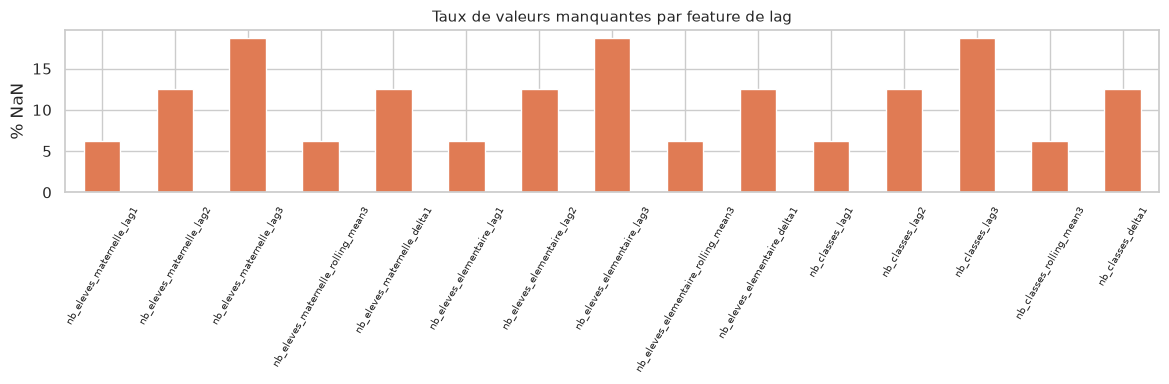


Lignes disponibles avec au moins lag1 : 645 / 688 (94%)


In [5]:
# Distribution des NaN par lag (les premières années manquent de contexte historique)
fig, ax = plt.subplots(figsize=(12, 4))

lag_null_pct = df_lag[lag_col_names].isnull().mean() * 100
colors = ['#e07b54' if v > 0 else '#1a9850' for v in lag_null_pct]
lag_null_pct.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Taux de valeurs manquantes par feature de lag', fontsize=11)
ax.set_ylabel('% NaN')
ax.tick_params(axis='x', rotation=60, labelsize=7)
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Dataset disponible après suppression des NaN
key_lags = [c for c in lag_col_names if 'lag1' in c]
df_lag_clean = df_lag.dropna(subset=key_lags)
print(f"\nLignes disponibles avec au moins lag1 : {len(df_lag_clean)} / {len(df_lag)} ({len(df_lag_clean)/len(df_lag)*100:.0f}%)")

## 3. Modèle avec features de lag : comparaison avant/après

In [6]:
from sklearn.model_selection import cross_val_score, KFold

base_features = [c for c in FEATURE_COLUMNS_ENGINEERED if c in df_lag.columns]
lag_features = get_lag_feature_names(ALL_TARGETS, lags=LAG_LAGS, rolling_windows=LAG_WINDOWS)
lag_features = [c for c in lag_features if c in df_lag.columns]

results_temporal = []
model = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)

for target in ALL_TARGETS:
    for fs_name, feat_cols in [
        ('Sans lag (base)', base_features),
        ('Avec lag (temporel)', base_features + lag_features),
    ]:
        valid_cols = [c for c in feat_cols if c in df_lag.columns]
        df_t = df_lag.dropna(subset=valid_cols + [target])
        if len(df_t) < 20:
            print(f"  Pas assez de données pour {target} / {fs_name} ({len(df_t)} lignes)")
            continue
        X = df_t[valid_cols].values
        y = df_t[target].values
        cv_scores = cross_val_score(
            model, X, y,
            cv=KFold(n_splits=5, shuffle=True, random_state=42),
            scoring='r2',
        )
        results_temporal.append({
            'target': target,
            'features': fs_name,
            'n_features': len(valid_cols),
            'n_samples': len(df_t),
            'cv_r2_mean': cv_scores.mean(),
            'cv_r2_std': cv_scores.std(),
        })

df_temporal = pd.DataFrame(results_temporal)
print(df_temporal.round(4).to_string(index=False))

               target            features  n_features  n_samples  cv_r2_mean  cv_r2_std
 nb_eleves_maternelle     Sans lag (base)           8        688      0.9918     0.0134
 nb_eleves_maternelle Avec lag (temporel)          23        559      0.9893     0.0141
nb_eleves_elementaire     Sans lag (base)           8        688      0.9883     0.0080
nb_eleves_elementaire Avec lag (temporel)          23        559      0.9947     0.0085
           nb_classes     Sans lag (base)           8        688      0.9811     0.0078
           nb_classes Avec lag (temporel)          23        559      0.9959     0.0049


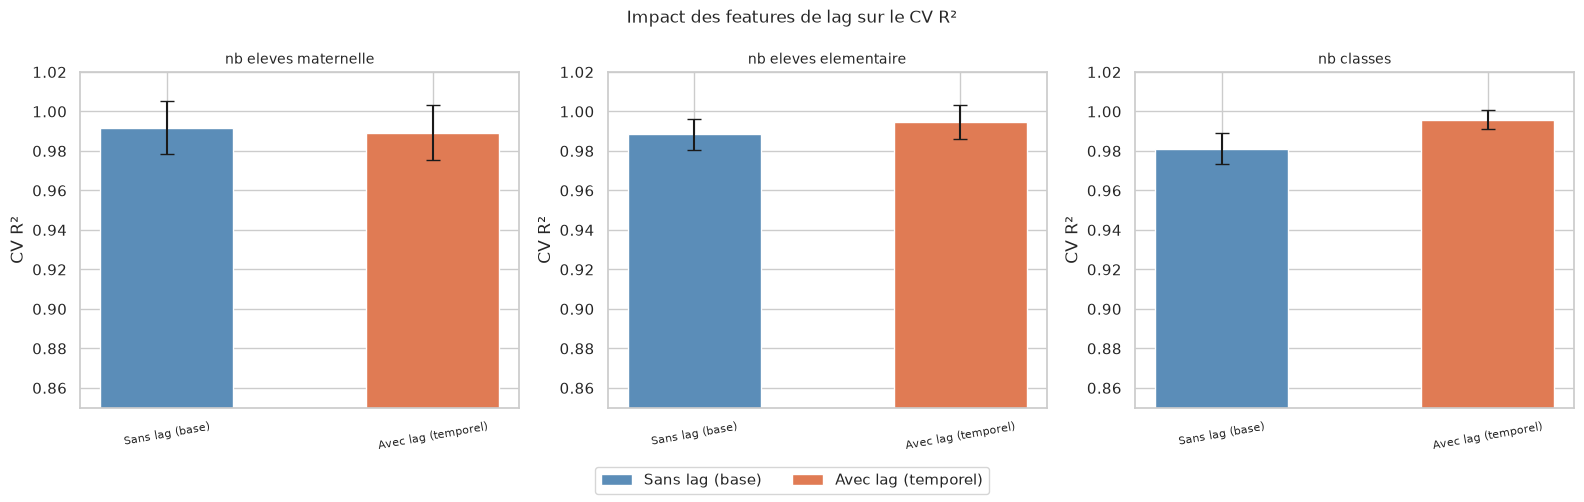

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_map = {'Sans lag (base)': '#5b8db8', 'Avec lag (temporel)': '#e07b54'}

for ax, target in zip(axes, ALL_TARGETS):
    sub = df_temporal[df_temporal['target'] == target]
    if sub.empty:
        ax.set_title(f'{target}\n(données insuffisantes)')
        continue
    x = np.arange(len(sub))
    ax.bar(
        x, sub['cv_r2_mean'],
        yerr=sub['cv_r2_std'],
        color=[colors_map.get(m, '#aaa') for m in sub['features']],
        capsize=5, width=0.5,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(sub['features'], fontsize=8, rotation=10)
    ax.set_ylim(0.85, 1.02)
    ax.set_ylabel('CV R²')
    ax.set_title(target.replace('_', ' '), fontsize=10)

from matplotlib.patches import Patch
leg = [Patch(facecolor=v, label=k) for k, v in colors_map.items()]
fig.legend(handles=leg, loc='lower center', ncol=2)
plt.suptitle('Impact des features de lag sur le CV R²', fontsize=12)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## 4. Importance des features temporelles (SHAP)

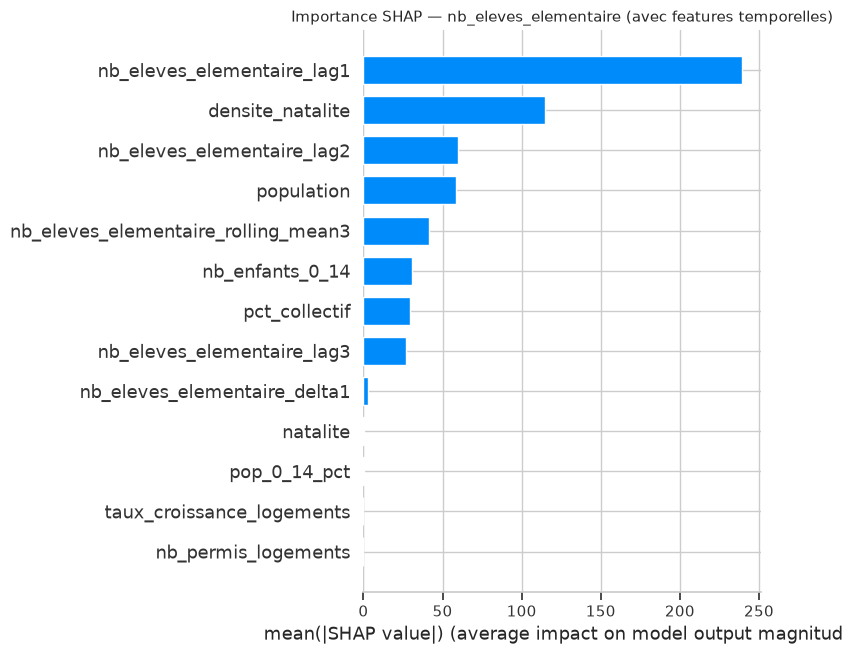

In [8]:
target = 'nb_eleves_elementaire'
all_feat = base_features + [c for c in lag_features if target.replace('nb_classes', 'nb_eleves') in c or 'elementaire' in c]
all_feat = list(dict.fromkeys(all_feat))  # dédoublonnage
all_feat = [c for c in all_feat if c in df_lag.columns]

df_shap = df_lag.dropna(subset=all_feat + [target])
X_shap = df_shap[all_feat].values
y_shap = df_shap[target].values

model_shap = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
model_shap.fit(X_shap, y_shap)

explainer = shap.TreeExplainer(model_shap)
shap_vals = explainer.shap_values(X_shap)

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_vals, X_shap, feature_names=all_feat, plot_type='bar', show=False, max_display=15)
plt.title(f'Importance SHAP — {target} (avec features temporelles)', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Prédiction de tendance avec Prophet

Prophet modélise la série temporelle de chaque commune individuellement :
- **trend** : croissance/décroissance à long terme
- **saisonnalité** : patterns annuels (cycles démographiques)
- **uncertainty intervals** : intervalles de confiance sur la prévision

In [9]:
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    print('Prophet disponible.')
except ImportError:
    PROPHET_AVAILABLE = False
    print('Prophet non installé. Installer avec : pip install prophet')
    print('Passage à ARIMA (statsmodels).')

Prophet non installé. Installer avec : pip install prophet
Passage à ARIMA (statsmodels).


In [10]:
# Communes avec suffisamment d'historique (>= 5 points)
commune_counts = df_raw.groupby('code_insee').size()
communes_ok = commune_counts[commune_counts >= 5].index.tolist()
print(f"{len(communes_ok)} communes avec >= 5 années d'historique")

# Sélection des 4 communes les plus peuplées pour la démo
top_communes = (
    df_raw[df_raw['code_insee'].isin(communes_ok)]
    .groupby('code_insee')['nb_eleves_elementaire'].mean()
    .nlargest(4)
    .index.tolist()
)
print(f"Communes démo : {top_communes}")

43 communes avec >= 5 années d'historique
Communes démo : ['35238', '35047', '35051', '35210']


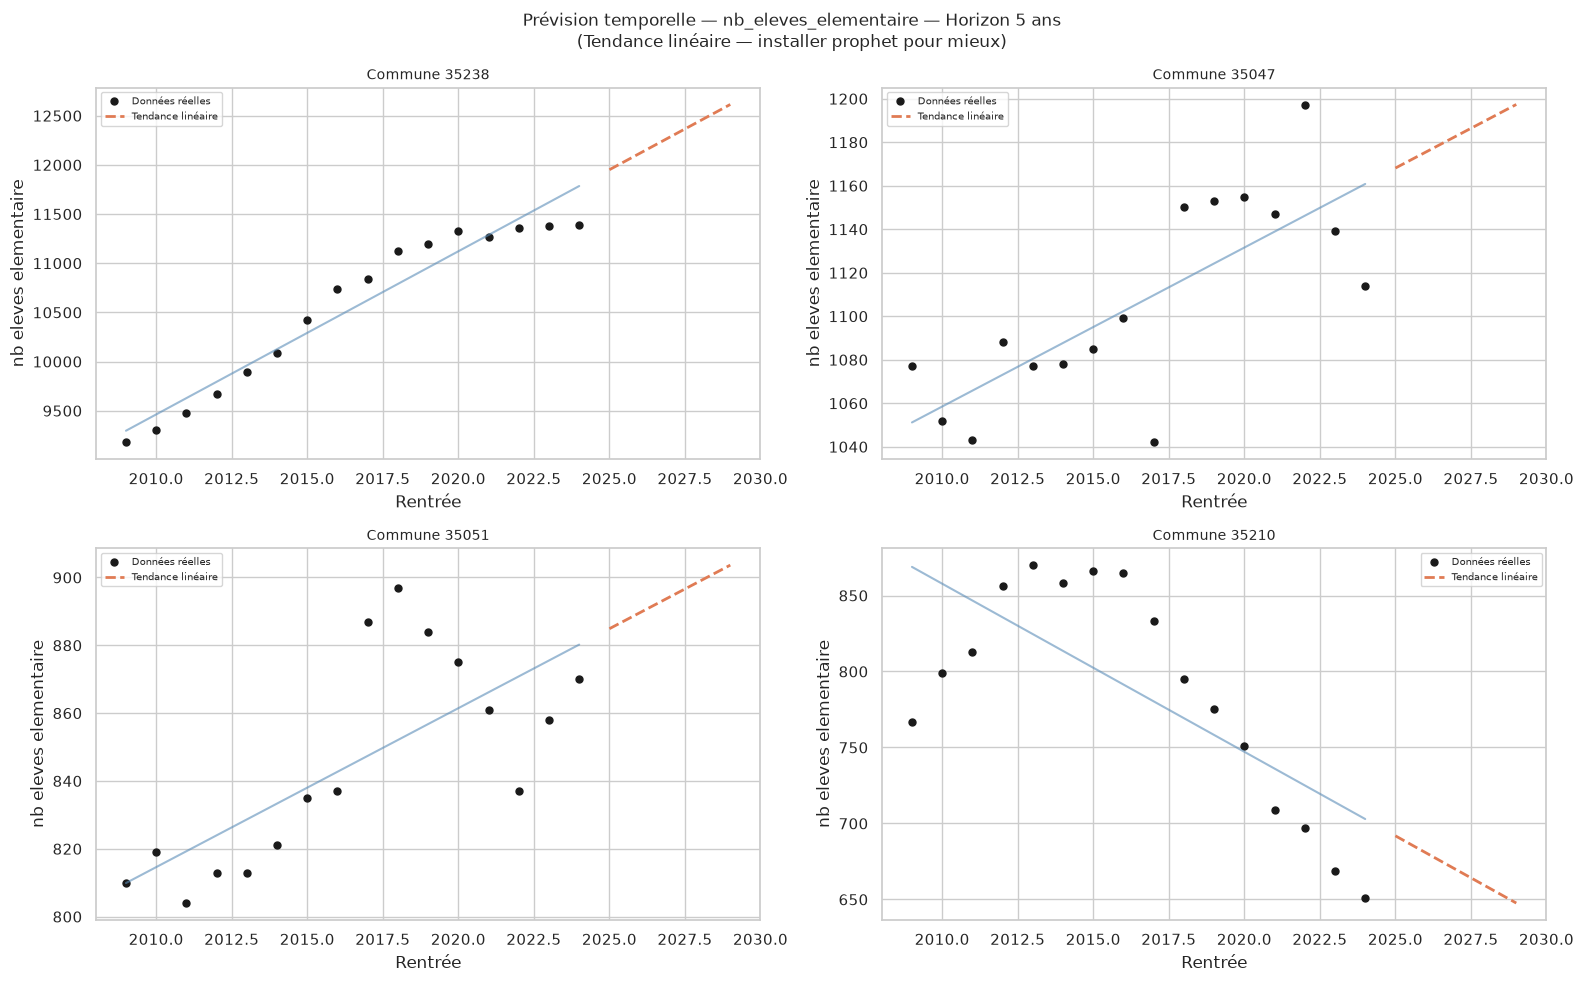

In [11]:
target = 'nb_eleves_elementaire'
HORIZON_YEARS = 5  # Prévision sur 5 ans

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, code_insee in zip(axes, top_communes):
    df_commune = df_raw[df_raw['code_insee'] == code_insee][['rentree', target]].dropna().copy()
    df_commune = df_commune.sort_values('rentree')

    if PROPHET_AVAILABLE:
        # Prophet : la colonne 'ds' doit être une date
        df_prophet = df_commune.rename(columns={'rentree': 'ds', target: 'y'})
        df_prophet['ds'] = pd.to_datetime(df_prophet['ds'].astype(str) + '-09-01')  # Rentrée = septembre

        m = Prophet(
            yearly_seasonality=False,  # Pas de cycle intra-annuel (données annuelles)
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.1,  # Régularisation des points de rupture
            interval_width=0.8,
        )
        m.fit(df_prophet)

        future = m.make_future_dataframe(periods=HORIZON_YEARS, freq='YS')
        forecast = m.predict(future)

        ax.fill_between(
            forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
            alpha=0.25, color='#5b8db8', label='Intervalle 80%',
        )
        ax.plot(forecast['ds'], forecast['yhat'], color='#5b8db8', linewidth=2, label='Prévision Prophet')
        ax.plot(
            pd.to_datetime(df_commune['rentree'].astype(str) + '-09-01'),
            df_commune[target],
            'ko', markersize=5, label='Données réelles',
        )
    else:
        # Fallback : regression linéaire simple sur la tendance
        from numpy.polynomial import polynomial as P
        x_hist = df_commune['rentree'].values
        y_hist = df_commune[target].values
        coefs = np.polyfit(x_hist, y_hist, 1)
        x_future = np.arange(x_hist[-1] + 1, x_hist[-1] + HORIZON_YEARS + 1)
        y_future = np.polyval(coefs, x_future)
        ax.plot(x_hist, y_hist, 'ko', markersize=5, label='Données réelles')
        ax.plot(x_future, y_future, '--', color='#e07b54', linewidth=2, label='Tendance linéaire')
        ax.plot(x_hist, np.polyval(coefs, x_hist), color='#5b8db8', linewidth=1.5, alpha=0.6)

    ax.set_title(f'Commune {code_insee}', fontsize=10)
    ax.set_xlabel('Rentrée')
    ax.set_ylabel(target.replace('_', ' '))
    ax.legend(fontsize=7)

plt.suptitle(
    f'Prévision temporelle — {target} — Horizon {HORIZON_YEARS} ans\n'
    + ('(Prophet)' if PROPHET_AVAILABLE else '(Tendance linéaire — installer prophet pour mieux)'),
    fontsize=12,
)
plt.tight_layout()
plt.show()

## 6. Validation temporelle : entraîner sur N-1 ans, prédire sur N

Méthode correcte pour les séries temporelles : ne **jamais** utiliser des données futures pour entraîner le modèle.

In [12]:
# TimeSeriesSplit : chaque fold entraîne sur toutes les années précédentes
from sklearn.model_selection import TimeSeriesSplit

target = 'nb_eleves_elementaire'
feat_lag = base_features + [c for c in lag_features if 'elementaire' in c]
feat_lag = [c for c in feat_lag if c in df_lag.columns]

df_ts = df_lag.dropna(subset=feat_lag + [target]).sort_values('rentree')

if len(df_ts) > 20:
    tscv = TimeSeriesSplit(n_splits=min(4, df_ts['rentree'].nunique() - 2))
    ts_model = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)

    ts_results = []
    X_ts = df_ts[feat_lag].values
    y_ts = df_ts[target].values
    rentrees_ts = df_ts['rentree'].values

    for fold_i, (train_idx, test_idx) in enumerate(tscv.split(X_ts)):
        ts_model.fit(X_ts[train_idx], y_ts[train_idx])
        y_pred = ts_model.predict(X_ts[test_idx])
        r2 = r2_score(y_ts[test_idx], y_pred)
        mae = mean_absolute_error(y_ts[test_idx], y_pred)
        train_rentrees = f"{rentrees_ts[train_idx].min()}-{rentrees_ts[train_idx].max()}"
        test_rentrees = f"{rentrees_ts[test_idx].min()}-{rentrees_ts[test_idx].max()}"
        ts_results.append({
            'fold': fold_i + 1,
            'train_rentrees': train_rentrees,
            'test_rentrees': test_rentrees,
            'r2': r2, 'mae': mae,
            'n_test': len(test_idx),
        })

    df_ts_res = pd.DataFrame(ts_results)
    print(f"Validation temporelle (TimeSeriesSplit) — cible : {target}")
    print(df_ts_res.round(3).to_string(index=False))
    print(f"\nR² moyen : {df_ts_res['r2'].mean():.4f} ± {df_ts_res['r2'].std():.4f}")
else:
    print(f"Données insuffisantes après ajout des lags ({len(df_ts)} lignes disponibles).")
    print("Ajoutez plus d'années d'historique dans la base pour activer la validation temporelle.")

Validation temporelle (TimeSeriesSplit) — cible : nb_eleves_elementaire
 fold train_rentrees test_rentrees    r2    mae  n_test
    1      2012-2014     2014-2017 0.996 28.352     111
    2      2012-2017     2017-2019 0.944 63.663     111
    3      2012-2019     2019-2022 1.000 18.710     111
    4      2012-2022     2022-2024 1.000 16.757     111

R² moyen : 0.9850 ± 0.0273


## 7. Conclusions & Guide d'utilisation en production

### Quand les lags sont utiles

Les features de lag apportent une amélioration si :
- Il y a **≥ 5 années d'historique** par commune
- La dynamique temporelle est **non-stationnaire** (croissance/décroissance visible)

### Utilisation en production

```python
from p13.ml.train import train_all

# Modèle temporel complet : feature engineering + lags + validation spatiale
results = train_all(
    use_engineering=True,
    use_spatial_cv=True,
    use_lags=True,  # Nécessite plusieurs années dans ml_dataset_commune
)
```

### Prérequis pour les lags

La table `ml_dataset_commune` doit contenir **plusieurs années** par commune.
Vérifier avec :
```sql
SELECT code_insee, COUNT(*) as n_rentrees 
FROM ml_dataset_commune 
GROUP BY code_insee 
ORDER BY n_rentrees DESC;
```

### Tableau de synthèse

| Scénario | Features | CV | Complexité |
|---|---|---|---|
| Baseline (actuel) | 4 numériques | KFold aléatoire | Faible |
| + Feature Engineering | 8 features | KFold aléatoire | Faible |
| + Validation Spatiale | 8 features | GroupKFold | Moyenne |
| + Séries Chronologiques | 8 + lags | TimeSeriesSplit | Haute |
| Complet | Tout | Spatial + Temporel | Haute |